<a href="https://colab.research.google.com/github/sheCodesAI/stats/blob/main/Normal_distribution_%26_Z_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd

In [53]:
data = pd.read_csv('/content/weight-height.csv')

In [54]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [55]:
data.drop(columns=['Weight'], inplace=True)
print("DataFrame head after dropping 'Weight' column (inplace):")
display(data.head())

DataFrame head after dropping 'Weight' column (inplace):


,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [56]:
data.Height.describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [57]:
# using seaborn lib, we will plot bell curve and histogram

In [58]:
import seaborn as sns

In [59]:
from numpy import histogram

<Axes: xlabel='Height', ylabel='Count'>

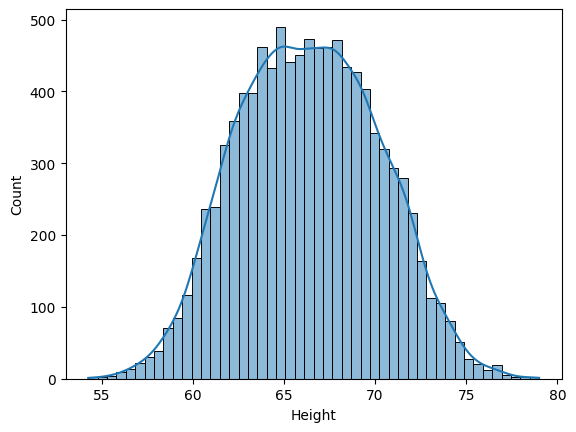

In [60]:
sns.histplot(data.Height, kde = True)
# bell curve with histogram

In [61]:
mean = data.Height.mean()
mean

np.float64(66.36755975482124)

In [62]:
stdd = data.Height.std()
stdd

3.8475281207732324

## **Range is -3 SD to +3 SD  for considering outliers**

In [63]:
mean - 3*stdd

np.float64(54.82497539250154)

In [64]:
mean + 3*stdd

np.float64(77.91014411714094)

In [65]:
data[ (data.Height > 77.91) | (data.Height < 52.82) ]

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374


In [69]:
data_no_outlier = data[ (data.Height > 77.91) | (data.Height < 52.82) ]
data_no_outlier

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374


In [67]:
data_no_outlier.shape

(5, 2)

## **Z score** means how many SD away a datapoint is from Mean, imagine from statisticians bell curve
### Z-score = how far a value is from the average (mean)

formula is : z = (every data point - avg) / SD

In [77]:
data['zscore'] = (data.Height - data.Height.mean()) / data.Height.std()

In [84]:
data[data['zscore']<-3]

,Gender,Height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [85]:
data[data['zscore']>3]

,Gender,Height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [98]:
data[(data['zscore']<-3) | (data['zscore']>3)]

,Gender,Height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [88]:
data.Height.mean()

np.float64(66.36755975482124)

In [90]:
data.Height.std()

3.8475281207732324

In [93]:
data.head(2)

,Gender,Height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505


In [92]:
(73.8470 - 66.36755975482124) / (3.8475281207732324)
# z score

1.9439598647236445

In [100]:
data_no_outlier = data[(data['zscore']>-3) & (data['zscore']<3)]
data_no_outlier

,Gender,Height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090


In [101]:
data_no_outlier.shape

(9993, 3)

In [ ]:
# initially 10000 were there but after removing outliers we removed 7 , and became count s 9993